In [81]:
import numpy as np
import pandas as pd

In [82]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [83]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [84]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [85]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [86]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [87]:
df.columns = df.columns.str.lower()

In [88]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [89]:
df['contract'].value_counts()

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [90]:
df['contract'].value_counts()

contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [91]:
df['paymentmethod'] = df['paymentmethod'].str.replace('(automatic)','', regex=False).str.strip()

In [92]:
df['paymentmethod'].value_counts()

paymentmethod
Electronic check    2365
Mailed check        1612
Bank transfer       1544
Credit card         1522
Name: count, dtype: int64

In [93]:
# Now this much preprocessing is enough to take the data into query analysis.
# We will split the columns into three tables 
# The three tables will be Customer, Services, Billing

In [94]:
customers_df = df[['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure']]

services_df = df[['customerid', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies']]

billing_df = df[['customerid', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']]

In [ ]:
from sqlalchemy import create_engine

username = 'postgres'
password = '123456'
host = 'localhost'
port = '5432'
database = 'Customer_Churn_Analysis'

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

customers_df.to_sql('customers', engine, if_exists='replace', index=False)
services_df.to_sql('services', engine, if_exists='replace', index=False)
billing_df.to_sql('billing', engine, if_exists='replace', index=False)

print(f"Database successfully loaded into {database}")



Importing ML Features from Postgres

In [95]:
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")


In [96]:
df = pd.read_sql('Select * from ml_feature', engine)

In [97]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,churn,tenure_segment,total_services,avg_revenue_per_month,contract,paymentmethod,monthlycharges,totalcharges
0,7590-VHVEG,Female,0,Yes,No,1,No,New,1,29.85,Month-to-month,Electronic check,29.85,29.85
1,5575-GNVDE,Male,0,No,No,34,No,Mature,3,55.57,One year,Mailed check,56.95,1889.5
2,3668-QPYBK,Male,0,No,No,2,Yes,New,3,54.08,Month-to-month,Mailed check,53.85,108.15
3,7795-CFOCW,Male,0,No,No,45,No,Mature,3,40.91,One year,Bank transfer,42.30,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,New,2,75.83,Month-to-month,Electronic check,70.70,151.65


In [98]:
df.shape

(7043, 14)

In [99]:
df.isnull().sum()

customerid                0
gender                    0
seniorcitizen             0
partner                   0
dependents                0
tenure                    0
churn                     0
tenure_segment            0
total_services            0
avg_revenue_per_month    11
contract                  0
paymentmethod             0
monthlycharges            0
totalcharges              0
dtype: int64

In [100]:
df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [101]:
df['avg_revenue_per_month'] = df['avg_revenue_per_month'].fillna(0)

In [102]:
df.isnull().sum()

customerid               0
gender                   0
seniorcitizen            0
partner                  0
dependents               0
tenure                   0
churn                    0
tenure_segment           0
total_services           0
avg_revenue_per_month    0
contract                 0
paymentmethod            0
monthlycharges           0
totalcharges             0
dtype: int64

In [104]:
# Label Encoder

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

encoder = LabelEncoder()
df['tenure_segment'] = encoder.fit_transform(df['tenure_segment'])

In [112]:
X = df.drop(columns=['customerid', 'churn'])
Y = df['churn']

In [116]:
nominal_cols = ['gender', 'partner', 'dependents', 'contract', 'paymentmethod']
num_cols = ['tenure', 'monthlycharges', 'totalcharges', 'total_services', 'avg_revenue_per_month', 'tenure_segment']

In [117]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = ohe.fit_transform(X[nominal_cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(nominal_cols), index=X.index)

X = X.drop(columns=nominal_cols)

X = pd.concat([X.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

In [118]:
X.head()

,seniorcitizen,tenure,tenure_segment,total_services,avg_revenue_per_month,monthlycharges,totalcharges,gender_Female,gender_Male,partner_No,partner_Yes,dependents_No,dependents_Yes,contract_Month-to-month,contract_One year,contract_Two year,paymentmethod_Bank transfer,paymentmethod_Credit card,paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,1,3,1,29.85,29.85,29.85,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,34,2,3,55.57,56.95,1889.5,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,2,3,3,54.08,53.85,108.15,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,45,2,3,40.91,42.30,1840.75,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,2,3,2,75.83,70.70,151.65,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [119]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: object

In [122]:
X[num_cols].isnull().sum()
for col in num_cols:
    print(col, X[col].dtype)

tenure int64
monthlycharges float64
totalcharges object
total_services int64
avg_revenue_per_month float64
tenure_segment int32


In [125]:
X['totalcharges'] = pd.to_numeric(X['totalcharges'], errors='coerce')
X['totalcharges'] = X['totalcharges'].fillna(0)

In [126]:
X.isnull().sum()

seniorcitizen                     0
tenure                            0
tenure_segment                    0
total_services                    0
avg_revenue_per_month             0
monthlycharges                    0
totalcharges                      0
gender_Female                     0
gender_Male                       0
partner_No                        0
partner_Yes                       0
dependents_No                     0
dependents_Yes                    0
contract_Month-to-month           0
contract_One year                 0
contract_Two year                 0
paymentmethod_Bank transfer       0
paymentmethod_Credit card         0
paymentmethod_Electronic check    0
paymentmethod_Mailed check        0
dtype: int64

In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [128]:
X.head()


,seniorcitizen,tenure,tenure_segment,total_services,avg_revenue_per_month,monthlycharges,totalcharges,gender_Female,gender_Male,partner_No,partner_Yes,dependents_No,dependents_Yes,contract_Month-to-month,contract_One year,contract_Two year,paymentmethod_Bank transfer,paymentmethod_Credit card,paymentmethod_Electronic check,paymentmethod_Mailed check
0,0,-1.277445,1.226315,-1.307868,-1.151310,-1.160323,-0.992611,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,0.066327,0.281768,-0.022897,-0.301582,-0.259629,-0.172165,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0,-1.236724,1.226315,-0.022897,-0.350808,-0.362660,-0.958066,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0.514251,0.281768,-0.022897,-0.785914,-0.746535,-0.193672,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0,-1.236724,1.226315,-0.665382,0.367760,0.197365,-0.938874,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [137]:
y = y.map({'Yes': 1, 'No': 0})

Splitting the Data into Train and Test

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [141]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

# Random Forest with tuning
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# XGBoost with tuning
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    param_distributions=xgb_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc')

In [144]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf.best_estimator_,
    'XGBoost': xgb.best_estimator_
}

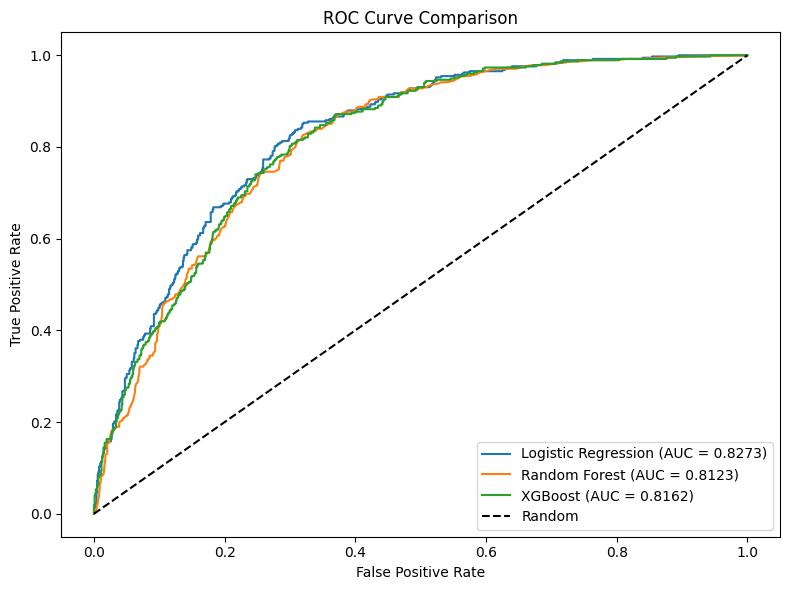

In [146]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()


In [148]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_prob)
    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc:.4f}")



Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409

ROC-AUC: 0.8273

Model: Random Forest
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1035
           1       0.54      0.60      0.57       374

    accuracy                           0.76      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.76      0.76      1409

ROC-AUC: 0.8123

Model: XGBoost
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1035
           1       0.54      0.59      0.56       374

    accuracy                           0.76      1409
   macro avg       0.69      0

C:\Users\terrm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


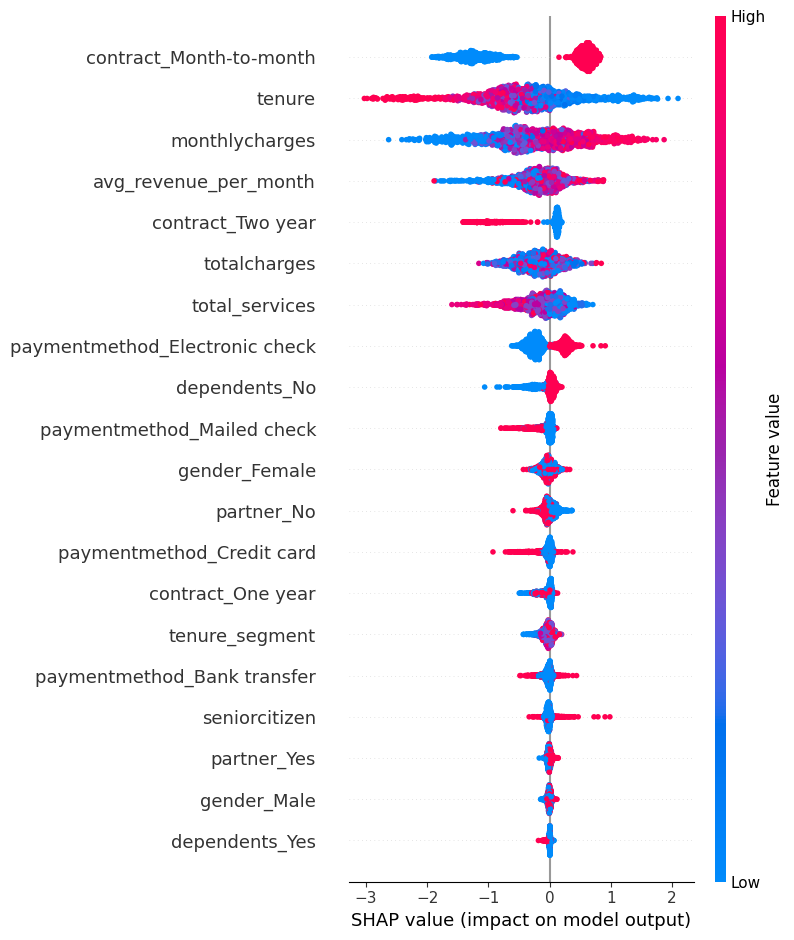

In [153]:
import shap

explainer = shap.TreeExplainer(xgb.best_estimator_)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

In [154]:
y_prob = xgb.best_estimator_.predict_proba(X_test)[:, 1]
y_pred = xgb.best_estimator_.predict(X_test)

In [155]:
y_prob

array([0.00385599, 0.94124097, 0.14711027, ..., 0.01399362, 0.08431199,
       0.01206507], dtype=float32)

In [156]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [163]:
import pickle

# Save the best model
with open('model.pkl', 'wb') as f:
    pickle.dump(xgb.best_estimator_, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the OneHotEncoder
with open('ohe.pkl', 'wb') as f:
    pickle.dump(ohe, f)

# Save the LabelEncoder
with open('le.pkl', 'wb') as f:
    pickle.dump(encoder, f)

print("All saved successfully")

All saved successfully
